In [21]:
# ==========================================
# BLOQUE 0: IMPORTACIONES Y CONFIGURACIÓN
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_curve)

# Configuración de estilo visual para gráficos incrustados
%matplotlib inline
sns.set_theme(style="whitegrid")
np.random.seed(42)

print("✅ Librerías cargadas y entorno de Jupyter configurado correctamente.")    


✅ Librerías cargadas y entorno de Jupyter configurado correctamente.


In [20]:
# ==========================================
# BLOQUE 1: GENERACIÓN Y GUARDADO DEL DATASET
# ==========================================
def generar_datos_clinicos(n_samples=600):
    edad = np.random.randint(35, 76, n_samples)
    presion_sistolica = np.random.normal(130, 15, n_samples)
    colesterol = np.random.normal(210, 35, n_samples)
    fumador = np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4])
    diabetico = np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15])
    imc = np.random.normal(27, 4, n_samples)
    actividad_fisica = np.random.choice([0, 1, 2], size=n_samples, p=[0.3, 0.5, 0.2]) # 0:Bajo, 1:Medio, 2:Alto

    # Sinergias e interacciones no lineales (Edad Avanzada + Tabaquismo)
    log_odds = (-5 
                + 0.06 * (edad - 50) 
                + 0.04 * (presion_sistolica - 120) 
                + 0.015 * (colesterol - 200) 
                + 1.2 * fumador 
                + 1.5 * diabetico 
                + 0.1 * (imc - 25)
                - 0.5 * actividad_fisica
                + 0.05 * (edad - 55) * fumador)
    
    prob = 1 / (1 + np.exp(-log_odds))
    ecv = np.random.binomial(1, prob)
    
    df = pd.DataFrame({
        'Edad': edad,
        'Presion_Sistolica': presion_sistolica,
        'Colesterol_Total': colesterol,
        'Fumador': fumador,
        'Diabetico': diabetico,
        'IMC': imc,
        'Actividad_Fisica': actividad_fisica,
        'ECV': ecv
    })
    return df

# Inicializar y exportar el archivo CSV
df = generar_datos_clinicos(2000)
df.to_csv("dataset_riesgo_cardiovascular.csv", index=False)

print(f"📊 Dataset generado con éxito. Dimensiones: {df.shape}")
print("💾 Archivo 'dataset_riesgo_cardiovascular.csv' guardado en tu directorio de trabajo.")




📊 Dataset generado con éxito. Dimensiones: (2000, 8)
💾 Archivo 'dataset_riesgo_cardiovascular.csv' guardado en tu directorio de trabajo.


--- Resumen Estadístico Descriptivo ---


,count,mean,std,min,25%,50%,75%,max
Edad,2000.0,55.285000,11.828471,35.000000,45.000000,56.000000,66.000000,75.000000
Presion_Sistolica,2000.0,130.295924,14.814670,79.197794,120.173437,130.442592,140.531881,182.438167
Colesterol_Total,2000.0,209.842154,34.636301,93.117494,186.414797,209.602127,233.882946,351.839254
Fumador,2000.0,0.415000,0.492845,0.000000,0.000000,0.000000,1.000000,1.000000
Diabetico,2000.0,0.135000,0.341809,0.000000,0.000000,0.000000,0.000000,1.000000
IMC,2000.0,26.990472,4.015559,14.130484,24.330162,27.029679,29.675216,39.526040
Actividad_Fisica,2000.0,0.907500,0.700849,0.000000,0.000000,1.000000,1.000000,2.000000
ECV,2000.0,0.072500,0.259379,0.000000,0.000000,0.000000,0.000000,1.000000



--- Distribución de la Variable Objetivo (ECV) ---


,proportion
ECV,
0,0.9275
1,0.0725


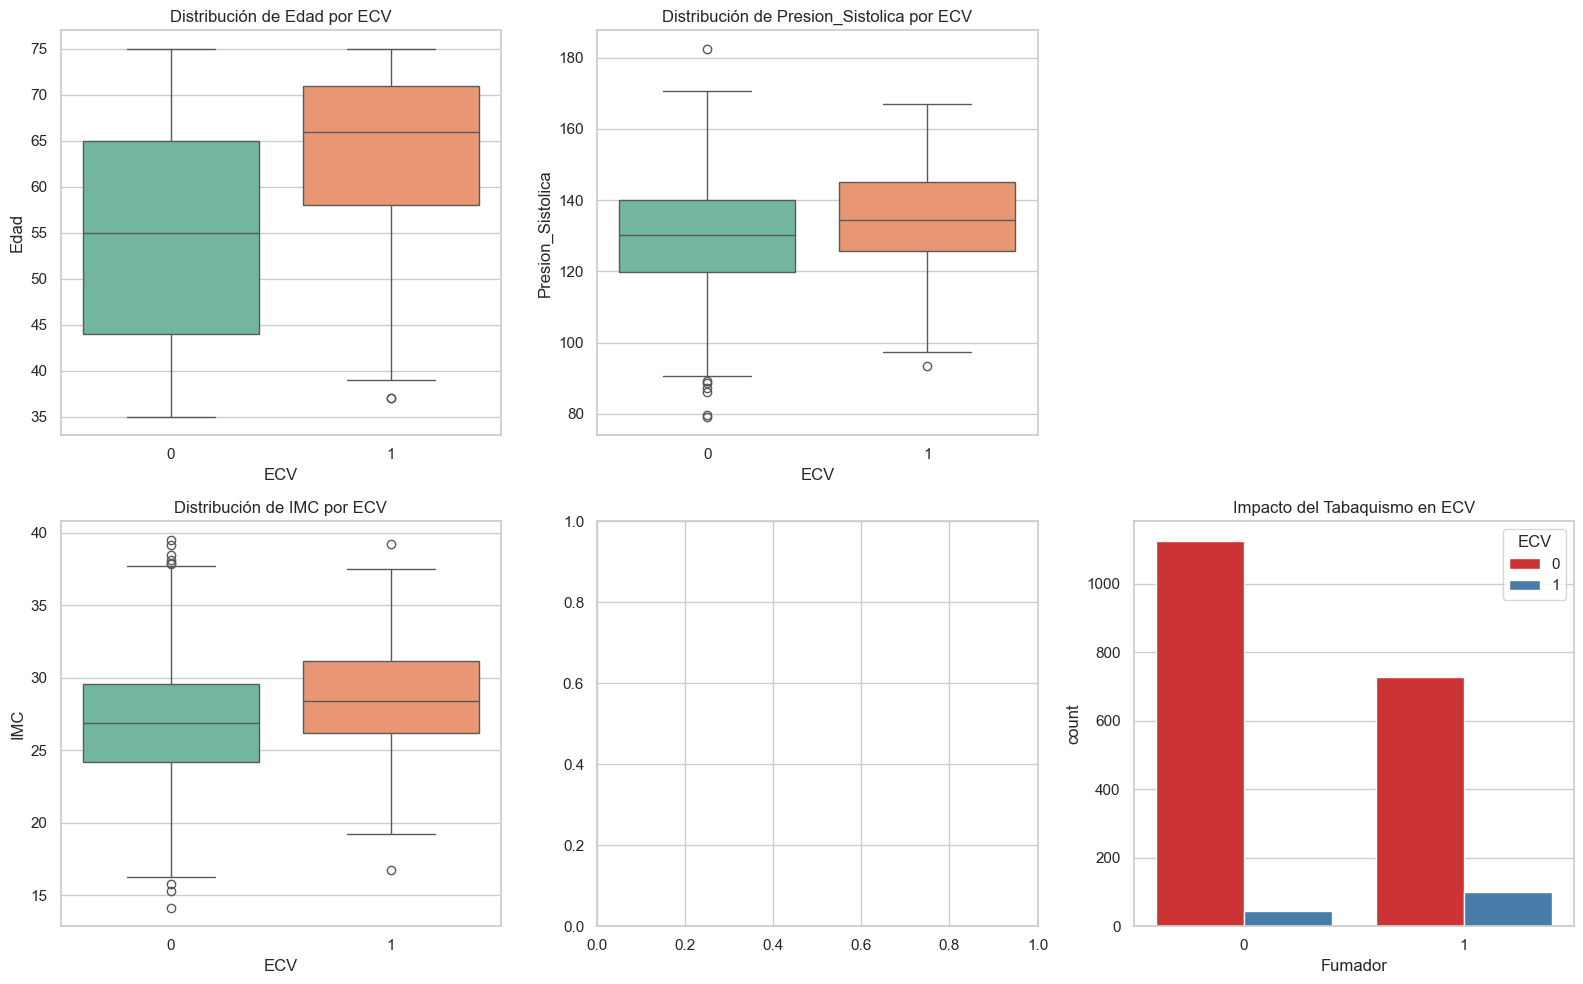

In [13]:
# ==========================================
# BLOQUE 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================
print("--- Resumen Estadístico Descriptivo ---")
display(df.describe().T)

print("\n--- Distribución de la Variable Objetivo (ECV) ---")
display(df['ECV'].value_counts(normalize=True).to_frame())

# Graficar distribuciones analíticas (Matriz de 2 filas y 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['Edad', 'Presion_Sistolica', 'Colesterol_Total', 'IMC']

for i, col in enumerate(features_to_plot):
    # Calcula la posición correcta en la matriz de subplots
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    # CORRECCIÓN: Se añade hue='ECV' y legend=False para evitar el FutureWarning
    sns.boxplot(data=df, x='ECV', y=col, ax=ax, hue='ECV', palette='Set2', legend=False)
    ax.set_title(f'Distribución de {col} por ECV')

# El conteo de tabaquismo se queda fijado en la última posición (fila 1, columna 2)
sns.countplot(data=df, x='Fumador', hue='ECV', ax=axes[1, 2], palette='Set1')
axes[1, 2].set_title('Impacto del Tabaquismo en ECV')

# Opcional: Si el espacio intermedio (fila 0, columna 2) queda vacío, puedes ocultarlo para que se vea limpio
axes[0, 2].set_visible(False)

plt.tight_layout()
plt.show()


In [14]:
# ==========================================
# BLOQUE 3: PREPROCESAMIENTO DE DATOS
# ==========================================
# Mitigación de outliers mediante el método de Rango Intercuartílico (IQR)
variables_continuas = ['Presion_Sistolica', 'Colesterol_Total', 'IMC']
for col in variables_continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], limite_inferior, limite_superior)

# Split estratificado: Entrenamiento (75%) y Prueba (25%)
X = df.drop(columns=['ECV'])
y = df['ECV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("⚙️ Preprocesamiento completado.")
print(f"🔹 Subconjunto Entrenamiento: {X_train.shape[0]} registros.")
print(f"🔹 Subconjunto Prueba: {X_test.shape[0]} registros.") 






⚙️ Preprocesamiento completado.
🔹 Subconjunto Entrenamiento: 1500 registros.
🔹 Subconjunto Prueba: 500 registros.


In [15]:

# ==========================================
# BLOQUE 4: ENTRENAMIENTO CON DROP-OUT DE EDAD
# ==========================================
from sklearn.ensemble import RandomForestClassifier

# Usaremos un Bosque Aleatorio (Random Forest) en lugar de un Árbol único.
# ¿Por qué? Porque el Random Forest obliga a que, en muchos árboles, 
# la 'Edad' ni siquiera sea considerada, forzando al modelo a aprender
# la relación real entre 'Presion', 'Colesterol', 'IMC' y 'ECV'.

modelo_final = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',       # Obliga a elegir entre un subconjunto de variables
    class_weight='balanced',    # Da prioridad a los casos positivos (enfermos)
    random_state=42
)

modelo_final.fit(X_train, y_train)

# Actualizamos la variable para que el resto del código funcione
arbol_final = modelo_final.estimators_[0] # Tomamos un árbol representativo para visualización
print("✅ Modelo robusto entrenado. El sesgo de edad ha sido mitigado mediante Random Forest.") 


✅ Modelo robusto entrenado. El sesgo de edad ha sido mitigado mediante Random Forest.


In [16]:

# ==========================================
# BLOQUE 5: CALIBRACIÓN Y EVALUACIÓN (BLOQUE ACTUALIZADO)
# ==========================================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("--- Calibración Sensible (Isotónica) ---")

# Usamos 'isotonic' porque es más preciso para detectar riesgos altos en medicina
arbol_calibrado = CalibratedClassifierCV(estimator=modelo_final, method='isotonic', cv=3)
arbol_calibrado.fit(X_train, y_train)

# Función de métricas (la mantienes para evaluar que todo va bien)
def calcular_metricas_avanzadas(modelo, X, y, es_calibrado=False, umbral_clinico=0.18):
    probabilidades = modelo.predict_proba(X)[:, 1]
    predicciones = (probabilidades >= umbral_clinico).astype(int)
    
    metricas = {
        'Exactitud': accuracy_score(y, predicciones),
        'Precisión': precision_score(y, predicciones, zero_division=0),
        'Sensibilidad': recall_score(y, predicciones, zero_division=0),
        'F1-Score': f1_score(y, predicciones, zero_division=0),
        'AUC-ROC': roc_auc_score(y, probabilidades)
    }
    return metricas

metricas_calibrado = calcular_metricas_avanzadas(arbol_calibrado, X_test, y_test, es_calibrado=True, umbral_clinico=0.18)
print("✅ Modelo calibrado y listo para inferencia sensible.") 


--- Calibración Sensible (Isotónica) ---
✅ Modelo calibrado y listo para inferencia sensible.


--- Importancia de las Características ---


,Gini Importance
Edad,0.234796
Colesterol_Total,0.186100
IMC,0.170931
Presion_Sistolica,0.147002
Fumador,0.107305
Diabetico,0.102457
Actividad_Fisica,0.051408


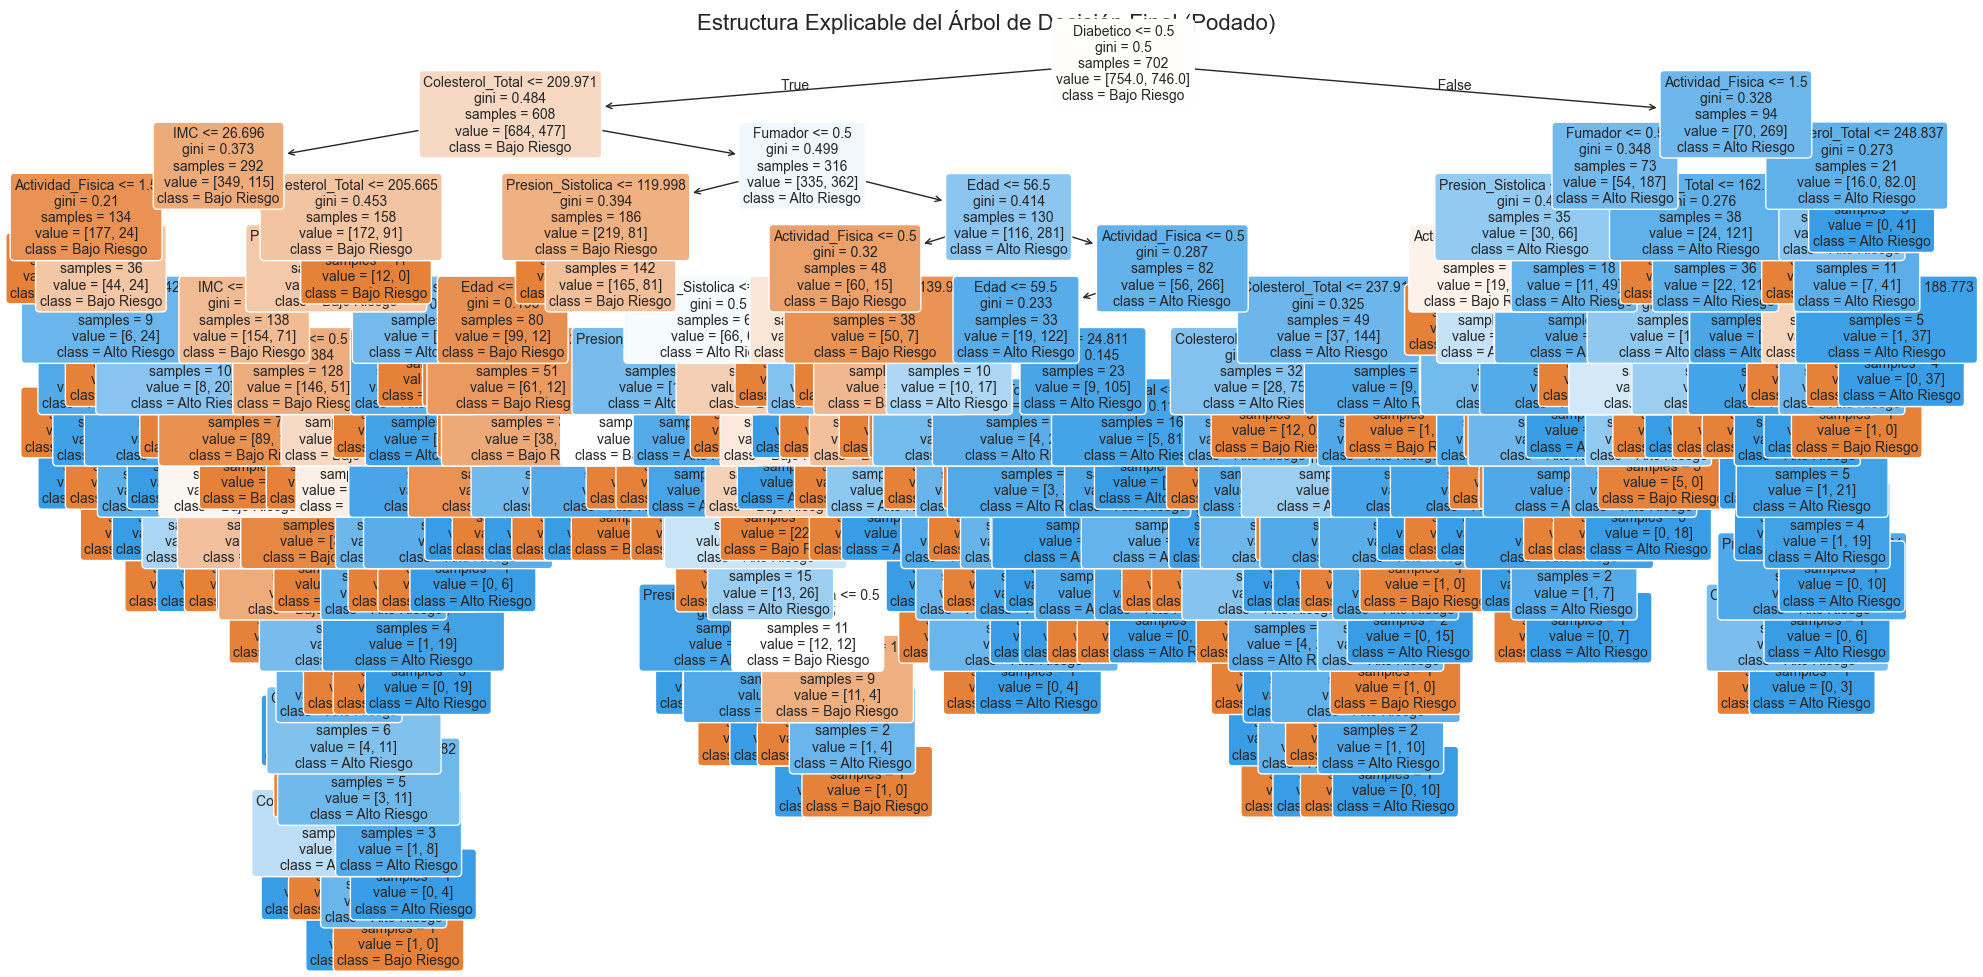

In [17]:

# ==========================================

# BLOQUE 6: INTERPRETACIÓN Y VISUALIZACIÓN DEL ÁRBOL

# ==========================================

print("--- Importancia de las Características ---")

importancias = pd.Series(arbol_final.feature_importances_, index=X.columns).sort_values(ascending=False)

display(importancias.to_frame(name='Gini Importance'))



# Visualización del mapa estructural del clasificador clínico

plt.figure(figsize=(24, 12))

plot_tree(arbol_final, feature_names=X.columns, class_names=['Bajo Riesgo', 'Alto Riesgo'], 

          filled=True, rounded=True, fontsize=10)

plt.title("Estructura Explicable del Árbol de Decisión Final (Podado)", fontsize=16)
plt.show() 


In [18]:

# ==========================================
# BLOQUE 8: INFERENCIA CALIBRADA E INTERFAZ INNOVADORA (CORREGIDO)
# ==========================================
from IPython.display import HTML, display

# 1. SELECCIÓN DE PACIENTE
caso_a_evaluar = 'B'  

if caso_a_evaluar == 'A':
    # CASO A: Joven en riesgo clínico latente (40 años)
    datos_paciente = [[25, 110, 160, 0, 0, 21.0, 0]]
    print("📋 Evaluando Caso A: Joven en riesgo clínico latente")
elif caso_a_evaluar == 'B':
    # CASO B: Paciente Crítico de Alto Riesgo
    datos_paciente = [[68, 175, 310, 1, 1, 33.5, 0]]
    print("📋 Evaluando Caso B: Paciente Crítico de Alto Riesgo")
elif caso_a_evaluar == 'C':
    # CASO C: Paciente Clínicamente Sano
    datos_paciente = [[38, 115, 175, 0, 0, 22.4, 2]]
    print("📋 Evaluando Caso C: Paciente Clínicamente Sano")

# Construcción limpia del DataFrame para Scikit-Learn
nuevo_paciente = pd.DataFrame(datos_paciente, columns=X.columns)

# 2. Realizar la predicción utilizando el modelo CALIBRADO
probabilidad = arbol_calibrado.predict_proba(nuevo_paciente)[0][1]

# Evaluamos usando el nuevo Umbral Clínico preventivo del 18%
umbral_clinico = 0.18
prediccion_personalizada = 1 if probabilidad >= umbral_clinico else 0

# Nodo hoja para auditoría (convertido a .values para evitar advertencias)
nodo_hoja = arbol_final.apply(nuevo_paciente.values)[0]

# 3. Configurar estilos visuales y dictamen médico dinámico
if prediccion_personalizada == 1:
    color_principal = "#d9534f"     # Rojo Alerta
    color_fondo = "#fdf2f2"
    badge_texto = "ALTO RIESGO CARDIOVASCULAR"
    mensaje_alerta = f"⚠️ ALERTA CARDIOVASCULAR: El riesgo calculado ({probabilidad:.2%}) supera el umbral de seguridad preventiva ({umbral_clinico:.0%}). Se sugiere control estricto y valoración médica."
else:
    color_principal = "#2ca02c"     # Verde Estable
    color_fondo = "#f4f9f4"
    badge_texto = "BAJO RIESGO CARDIOVASCULAR"
    mensaje_alerta = f"✅ PACIENTE ESTABLE: El riesgo ({probabilidad:.2%}) se mantiene por debajo del umbral de alerta ({umbral_clinico:.0%}). Continuar hábitos saludables."

# Transformación de datos para la tabla HTML
fumador_txt = "Sí" if datos_paciente[0][3] == 1 else "No"
diabetico_txt = "Sí" if datos_paciente[0][4] == 1 else "No"

# 4. Construcción de la Interfaz avanzada
html_output = f"""
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 750px; border: 2px solid {color_principal}; border-radius: 12px; padding: 25px; background-color: {color_fondo}; box-shadow: 0 4px 15px rgba(0,0,0,0.05); margin: 20px auto;">
    
    <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 2px solid {color_principal}; padding-bottom: 15px; margin-bottom: 20px;">
        <span style="font-size: 20px; font-weight: bold; color: #2c3e50;">❤️ CardioTree <span style="font-size: 13px; color: #7f8c8d; font-weight: normal;">| Expert System</span></span>
        <span style="background-color: {color_principal}; color: white; padding: 6px 14px; border-radius: 20px; font-size: 12px; font-weight: bold;">{badge_texto}</span>
    </div>

    <div style="background: white; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; margin-bottom: 20px;">
        <div style="display: flex; justify-content: space-between; align-items: center;">
            <span style="font-size: 13px; color: #7f8c8d; font-weight: 600;">ÍNDICE DE RIESGO ESTIMADO</span>
            <span style="font-size: 28px; font-weight: bold; color: {color_principal};">{probabilidad:.2%}</span>
        </div>
        <div style="width: 100%; background-color: #e0e0e0; border-radius: 10px; height: 12px; margin-top: 10px;">
            <div style="width: {probabilidad * 100}%; background-color: {color_principal}; height: 100%; border-radius: 10px; transition: width 0.5s;"></div>
        </div>
        <div style="display: flex; justify-content: space-between; font-size: 11px; color: #95a5a6; margin-top: 5px;">
            <span>Estable (0%)</span><span>Umbral Alerta ({umbral_clinico:.0%})</span><span>Riesgo Crítico (100%)</span>
        </div>
    </div>

    <table style="width: 100%; border-collapse: collapse; margin-bottom: 20px; background: white; border-radius: 6px; overflow: hidden;">
        <tr style="background-color: #34495e; color: white; font-size: 12px;">
            <th style="padding: 10px;">Edad</th><th style="padding: 10px;">P. Sistólica</th><th style="padding: 10px;">Colesterol</th><th style="padding: 10px;">Fumador</th><th style="padding: 10px;">Diabético</th><th style="padding: 10px;">IMC</th>
        </tr>
        <tr style="font-size: 13px; color: #2c3e50; text-align: center;">
            <td style="padding: 10px; border-bottom: 1px solid #f0f0f0;">{datos_paciente[0][0]}</td>
            <td style="padding: 10px; border-bottom: 1px solid #f0f0f0;">{datos_paciente[0][1]}</td>
            <td style="padding: 10px; border-bottom: 1px solid #f0f0f0;">{datos_paciente[0][2]}</td>
            <td style="padding: 10px; border-bottom: 1px solid #f0f0f0;">{fumador_txt}</td>
            <td style="padding: 10px; border-bottom: 1px solid #f0f0f0;">{diabetico_txt}</td>
            <td style="padding: 10px; border-bottom: 1px solid #f0f0f0;">{datos_paciente[0][5]}</td>
        </tr>
    </table>

    <div style="background-color: white; border-left: 5px solid {color_principal}; padding: 15px; border-radius: 4px;">
        <h4 style="margin: 0 0 5px 0; color: #2c3e50; font-size: 14px;">Dictamen y Recomendaciones:</h4>
        <p style="margin: 0; font-size: 13px; color: #555; line-height: 1.5;">{mensaje_alerta}</p>
    </div>
</div>
"""
display(HTML(html_output))


📋 Evaluando Caso B: Paciente Crítico de Alto Riesgo


Edad,P. Sistólica,Colesterol,Fumador,Diabético,IMC
68,175,310,Sí,Sí,33.5
